# In-Depth Linear Regression Example

[Resource](https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html)

In this section, we'll start with a quick intuitive walk-through of the mathematics behind this well-known problem, before seeing how before moving on to see how linear models can be generalized to account for more complicated patterns in data.

We begin with the standard imports:

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Simple Linear Regression

We will start with the most familiar linear regression, a straight-line fit to data. You're already very familiar with this so let's just get it done.

Consider the following data:

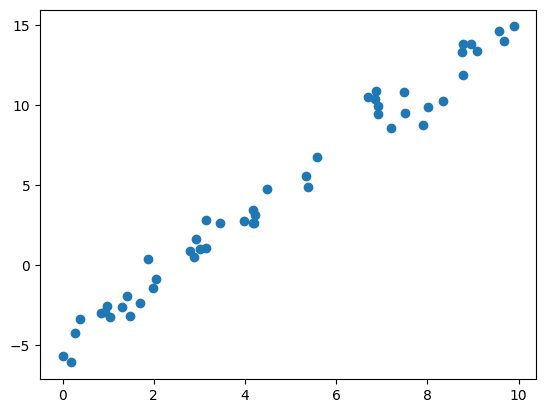

In [107]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)
plt.scatter(x, y);

We can use Scikit-Learn's `LinearRegression` estimator to fit this data and construct the best-fit line:

`x` shape: (50,)
`x` new axis shape: (50, 1)


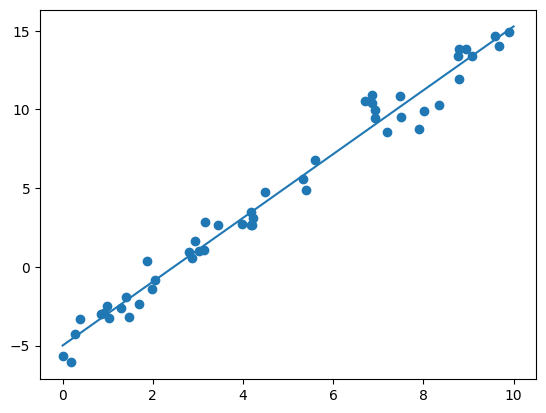

In [108]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True) # True by default
model.fit(x[:, np.newaxis], y)

print(f"`x` shape: {x.shape}\n`x` new axis shape: {x[:, np.newaxis].shape}")

xfit = np.linspace(0, 10, 1000)
yfit = model.predict(xfit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(xfit, yfit);

The slope and intercept of the data are contained in the model's fit parameters, which in Scikit-Learn are always marked by a trailing underscore. here the relevant parameters are `coef_` and `intercept_`:

In [109]:
print(f"Model slope: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Model slope: [2.02720881]
Model intercept: -4.998577085553202


We see that the results are very close to the inputs, as we might hope.

The `LinearRegression` estimator is much more capable than this, however - in addition to simple straight line fits, it can also handle multidimensional linear models of the form

y=a0+a1x1+a2x2+⋯

where there are multiple x values. Geometrically, this is akin to fitting a plane to points in three dimensions, or fitting a hyper-plane to points in higher dimensions.

The multidimensional nature of such regression makes them more difficult to visualize, but we can see one of these fits in action by building some example data.

In [110]:
rng = np.random.RandomState(1)
X = 10 * rng.rand(100, 3)
y = 0.5 + np.dot(X, [1.5, -2, 1.])

model.fit(X, y)
print(f"Slope: {model.intercept_:.2f}\nCoefficients: {model.coef_}")

Slope: 0.50
Coefficients: [ 1.5 -2.   1. ]


Here the *y* data is constructed from three random *x* values, and the linear regression recovers the coefficients used to construct the data.

In this way, we can use the single `LinearRegression` estimator to fit lines, planes, or hyperplanes to our data. It still appears that this approach would be limited to strictly linear relationships between variables, but it turns out we can relax this as well.

# Basis Function Regression

One trick you can use to adapt linear regression to nonlinear relationships between variables is to transform the data according to **basis functions**. The idea is to take our multidimensional linear model:

y=a0+a1x1+a2x2+a3x3+⋯

and build the x1, x2, x3, and so on, from our single-dimensional input *x*. that is, we let xn=fn(x), where fn() is some function that transforms our data.

For example, if fn(x)=x^n, our model becomes a polynomial regression:

y=a0+a1x+a2x2+a3x3+⋯

Clearly, this is still a linear model - the linearity refers to the fact that the coefficients never multiply or divide each other. What we've effectively done is taken our one-dimensional *x* values and projected them into a higher dimension, so that a linear fit can fit more complicated relationships between *x* and *y*.

## Polynomial Basis Functions

Let's get to it.

In [111]:
from sklearn.preprocessing import PolynomialFeatures

x = np.array([2, 3, 4])
poly = PolynomialFeatures(3, include_bias=False) # Include bias adds a column of 1s to the feature matrix to enable an intercept term
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

We see here that the transformer has converted our one-dimensional array into a three-dimensional array by taking the exponent of each value. This new, higher-dimensional data representation can then be plugged into a linear regression.

The cleanest way to accomplish this is to use a pipeline. Let's make a 7th-degree polynomial model in this way:

In [112]:
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(7),
                           LinearRegression())

With this transform in place, we can use the linear model to fit much more complicated relationships between *x* and *y*. For example, here's a sine wave with noise:

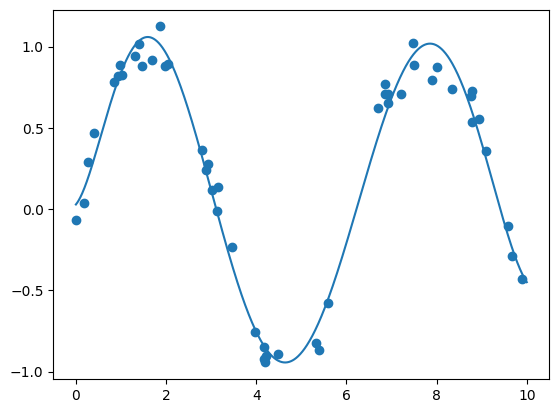

In [113]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)

poly_model.fit(x[:, np.newaxis], y)
yfit = poly_model.predict(xfit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(xfit, yfit);

Our linear model, through the use of the 7th-order polynomial basis functions, can provide an excellent fit to this non-linear data.

## Gaussian Basis Functions

Of course, other basis functions are 